# 04 — Modelo Baseado em Conteúdo (TF-IDF)
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Avalia o recomendador por similaridade de conteúdo usando TF-IDF dos textos das avaliações. O modelo é especialmente útil para cold-start: usuários novos, cuja filtragem colaborativa não consegue atender por falta de histórico.

**Base**: `tfidf_matrix.npz` (623 cursos × 5000 termos) gerada no notebook 02 — Ramo B.

**Objetivos desta etapa**:
- Construir perfis TF-IDF por usuário a partir das avaliações de treino
- Predizer ratings no test set mapeando similaridade coseno para a escala 1–5
- Avaliar qualidade em dois regimes: known-users (tem histórico) e cold-start

---
## 0. Setup

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importa modulos do projeto
sys.path.insert(0, str(Path.cwd().parent))
from src.content_model import ContentRecommender
from src.metrics import evaluate_all, precision_at_k, ndcg_at_k

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Imports OK')

Imports OK


---
## 1. Carregamento dos dados

Carrega a matriz TF-IDF (623 × 5000) e as triplas de treino/teste já preparadas no pipeline.

In [2]:
train_raw = pd.read_parquet('../data/surprise_train.parquet')
test_raw  = pd.read_parquet('../data/surprise_test.parquet')

content = ContentRecommender(rating_floor=3.0).load(
    '../data/tfidf_matrix.npz',
    '../data/tfidf_meta.parquet',
)

print(f'Matriz TF-IDF: {content.tfidf.shape[0]} cursos × {content.tfidf.shape[1]} termos')
print(f'Treino: {len(train_raw):,} triplas | {train_raw["reviewers"].nunique():,} users')
print(f'Teste:  {len(test_raw):,} triplas | {test_raw["reviewers"].nunique():,} users')

Matriz TF-IDF: 623 cursos × 5000 termos
Treino: 121,009 triplas | 49,066 users
Teste:  115,442 triplas | 50,552 users


---
## 2. Exploração: similaridade item–item

Validação qualitativa: dado um curso, os vizinhos mais próximos devem ser tematicamente coerentes.

In [3]:
courses_df = pd.read_parquet('../data/courses.parquet')
name_map = dict(zip(courses_df['course_id'], courses_df['name']))

probes = ['machine-learning', 'python', 'neural-networks-deep-learning', 'financial-markets']
for cid in probes:
    print(f'\n>>> Similar a "{name_map.get(cid, cid)}"')
    for other_id, sim in content.similar_courses(cid, top_n=5):
        print(f'  {sim:.3f}  {name_map.get(other_id, other_id)}')


>>> Similar a "Machine Learning"
  0.834  Applied Machine Learning in Python
  0.810  Machine Learning Foundations: A Case Study Approach
  0.804  Structuring Machine Learning Projects
  0.802  Machine Learning for All
  0.796  Introduction to Machine Learning

>>> Similar a "Programming for Everybody (Getting Started with Python)"
  0.872  Learn to Program: The Fundamentals
  0.867  Python Data Structures
  0.858  Python Programming: A Concise Introduction
  0.852  Python Basics
  0.838  Crash Course on Python

>>> Similar a "Neural Networks and Deep Learning"
  0.786  Improving Deep Neural Networks: Hyperparameter tuning, Regularization and Optimization
  0.692  Sequence Models
  0.689  Convolutional Neural Networks
  0.671  Structuring Machine Learning Projects
  0.643  Convolutional Neural Networks in TensorFlow

>>> Similar a "financial-markets"


---
## 3. Construção de perfis de usuário

Para cada usuário com pelo menos uma avaliação ≥ 3★ no treino, o perfil é a média ponderada (pelo rating) dos vetores TF-IDF dos cursos avaliados.

In [4]:
t0 = time.time()
content.build_user_profiles(train_raw)
t_fit = time.time() - t0

n_profiles = len(content.user_profiles)
print(f'Perfis construídos: {n_profiles:,} usuários ({t_fit:.1f}s)')
print(f'Usuários de treino sem perfil: {train_raw["reviewers"].nunique() - n_profiles:,} (sem rating ≥ 3★)')

Perfis construídos: 48,619 usuários (3.8s)
Usuários de treino sem perfil: 447 (sem rating ≥ 3★)


---
## 4. Predição no test set

Para cada tripla (user, course, rating_real) do test, geramos um rating previsto via similaridade entre o perfil do usuário e o vetor TF-IDF do curso. Se o usuário não tem perfil (cold-start), usamos 3.5 como score neutro.

In [5]:
# Divide o test em known-users (tem perfil) e cold-start (nao tem)
profile_users = set(content.user_profiles.keys())
test_known   = test_raw[test_raw['reviewers'].isin(profile_users)].copy()
test_cold    = test_raw[~test_raw['reviewers'].isin(profile_users)].copy()

print(f'Test known (tem perfil): {len(test_known):,} triplas | {test_known["reviewers"].nunique():,} users')
print(f'Test cold-start:         {len(test_cold):,} triplas | {test_cold["reviewers"].nunique():,} users')

Test known (tem perfil): 56,898 triplas | 24,127 users
Test cold-start:         58,544 triplas | 26,425 users


In [6]:
# Predicoes no regime known-users
triples_known = list(test_known[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))
t0 = time.time()
preds_known = content.predict_batch(triples_known)
print(f'Predições known: {len(preds_known):,} ({time.time()-t0:.1f}s)')

# Predicoes no regime cold-start
triples_cold = list(test_cold[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))
preds_cold = content.predict_batch(triples_cold)
print(f'Predições cold:  {len(preds_cold):,}')

Predições known: 56,898 (1.8s)
Predições cold:  58,544


---
## 5. Métricas

Avaliamos os dois regimes separadamente. O cold-start mede o comportamento degradado (fallback neutro) e serve de baseline inferior.

In [7]:
metrics_known = evaluate_all(preds_known, k_list=(5, 10))
metrics_cold  = evaluate_all(preds_cold,  k_list=(5, 10))
metrics_full  = evaluate_all(preds_known + preds_cold, k_list=(5, 10))

results = pd.DataFrame({
    'known-users': metrics_known,
    'cold-start':  metrics_cold,
    'full test':   metrics_full,
}).T.round(4)

results

,rmse,mae,precision@5,recall@5,f1@5,hit_rate@5,ndcg@5,precision@10,recall@10,f1@10,hit_rate@10,ndcg@10
known-users,1.1703,1.0536,0.3880,0.9693,0.5542,0.9675,0.9888,0.2161,0.9962,0.3551,0.9675,0.9911
cold-start,1.3945,1.3376,0.4094,0.9923,0.5796,0.9829,0.9920,0.2102,0.9993,0.3474,0.9829,0.9925
full test,1.2889,1.1976,0.3992,0.9814,0.5676,0.9755,0.9905,0.2130,0.9978,0.3511,0.9755,0.9918


---
## 6. Distribuição de similaridades

Inspeciona como os scores se distribuem. Scores concentrados perto de 3.0 indicam pouca discriminação (muitos perfis genéricos).

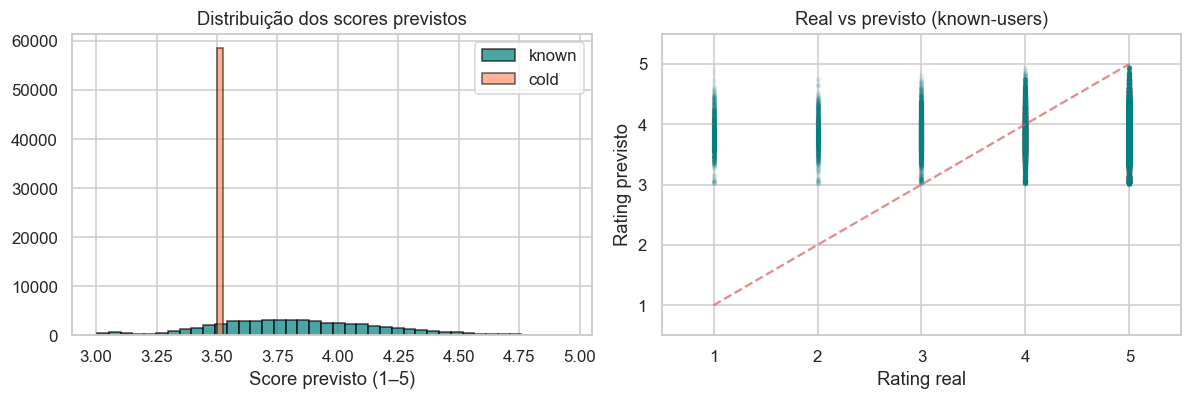

In [8]:
est_known = np.array([p[3] for p in preds_known])
est_cold  = np.array([p[3] for p in preds_cold])
real_known = np.array([p[2] for p in preds_known])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(est_known, bins=40, color='teal', alpha=0.7, edgecolor='black', label='known')
axes[0].hist(est_cold,  bins=40, color='coral', alpha=0.6, edgecolor='black', label='cold')
axes[0].set_title('Distribuição dos scores previstos')
axes[0].set_xlabel('Score previsto (1–5)')
axes[0].legend()

axes[1].scatter(real_known, est_known, alpha=0.03, s=6, color='teal')
axes[1].plot([1, 5], [1, 5], 'r--', alpha=0.7)
axes[1].set_xlabel('Rating real')
axes[1].set_ylabel('Rating previsto')
axes[1].set_title('Real vs previsto (known-users)')
axes[1].set_xlim(0.5, 5.5)
axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.show()

---
## 7. Top-10 para um usuário exemplo

Recomendação qualitativa: usa o perfil agregado para rankear cursos que o usuário ainda não avaliou.

In [9]:
sample_user = test_known['reviewers'].value_counts().index[0]
already = set(train_raw[train_raw['reviewers'] == sample_user]['course_id'])

top10 = content.recommend_for_user(sample_user, top_n=10, exclude=already)

print(f'Usuário: {sample_user}')
print(f'Cursos já avaliados no treino: {len(already)}')
print('\nTop-10 recomendações (content-based):')
for i, (cid, sim) in enumerate(top10, 1):
    print(f'  {i:2d}. sim={sim:.3f}  {name_map.get(cid, cid)}')

Usuário: Utkarsh S
Cursos já avaliados no treino: 5

Top-10 recomendações (content-based):
   1. sim=0.825  Python Functions, Files, and Dictionaries
   2. sim=0.810  Crash Course on Python
   3. sim=0.799  Learn to Program: The Fundamentals
   4. sim=0.796  Programming for Everybody (Getting Started with Python)
   5. sim=0.776  Introduction to Data Science in Python
   6. sim=0.765  Python for Data Science and AI
   7. sim=0.763  Object-Oriented Data Structures in C++
   8. sim=0.755  Python Programming: A Concise Introduction
   9. sim=0.750  Data Analysis with Python
  10. sim=0.746  C for Everyone: Programming Fundamentals


---
## 8. Persistência dos resultados

In [10]:
import os
os.makedirs('../data/results', exist_ok=True)

# Tabela com as metricas nos 3 regimes
results.to_parquet('../data/results/content_results.parquet')

# Predicoes completas (para comparacao no notebook 05)
preds_df = pd.DataFrame(
    [(p[0], p[1], p[2], p[3]) for p in preds_known + preds_cold],
    columns=['reviewers', 'course_id', 'rating_true', 'rating_est'],
)
preds_df['regime'] = ['known'] * len(preds_known) + ['cold'] * len(preds_cold)
preds_df.to_parquet('../data/results/content_preds.parquet')

print('Salvo:')
print('  data/results/content_results.parquet')
print('  data/results/content_preds.parquet')
print(f'Total predições: {len(preds_df):,}')

Salvo:
  data/results/content_results.parquet
  data/results/content_preds.parquet
Total predições: 115,442


---
## 9. Conclusão parcial

O modelo baseado em conteúdo não compete em RMSE/MAE com SVD ou KNN nos usuários com histórico — essa comparação direta é esperada porque o TF-IDF não otimiza erro de rating. Seu valor está no **cenário cold-start**, onde a filtragem colaborativa não opera por falta de interação.

No notebook **05_RESULTS_comparison** consolidamos este modelo junto aos baselines e aos modelos colaborativos, incluindo a avaliação do híbrido (switching SVD ↔ content-based).